# Sales Analytics Lab — From Descriptive Statistics to a Business Dashboard

**Course:** Intro to Data Science  
**Instructor:** Masoud Ahangari  
**Class format:** 3-hour guided lab  
**Dataset:** Clean order-level derivative of the UCI Online Retail dataset

---

## Learning goals

By the end of this notebook, you should be able to:

1. Translate a business question into a statistical question.
2. Use **mean, median, minimum, maximum, variance, and standard deviation** to summarize sales data.
3. Use **quartiles, percentiles, IQR, and outlier bounds** to describe the distribution of order values.
4. Read a **histogram** and a **box plot** as business analysis tools.
5. Explain **skewness conceptually** without using a skewness formula.
6. Use **NumPy masking** to identify high-value or unusual orders.
7. Interpret **covariance** between order quantity and order value.
8. Prepare a small set of metrics and charts for an executive sales dashboard.

> This notebook intentionally starts from a **clean dataset**. The goal is not data cleaning or EDA.  
> The goal is to use the descriptive-statistics concepts already covered in class on real sales data.

## 1. Business scenario

Imagine that you are part of the analytics team of an online retailer.

The business manager asks six questions:

1. **What does a typical order look like?**
2. **Is the average order value representative of most customers?**
3. **Do a small number of very large orders influence the summary statistics?**
4. **How variable are order values?**
5. **Do orders containing more units tend to generate more revenue?**
6. **How should we communicate the most important patterns in a dashboard?**

We will answer these questions step by step.

## 2. About the dataset

Each row represents **one completed order**.

The original transaction-level dataset was pre-cleaned for this class:

- cancelled invoices were removed,
- non-positive quantities and prices were removed,
- rows with missing core fields were removed,
- administrative/service lines were removed,
- product lines were aggregated to **one row per order**,
- statistical outliers were **not** removed.

The important point is that unusual orders are still present because they are useful for learning about **mean vs median, IQR, box plots, histograms, and skewness**.

### Main columns

| Column | Meaning |
|---|---|
| `OrderID` | Unique order/invoice identifier |
| `OrderDate` | Date of the order |
| `OrderMonth` | Month of the order |
| `CustomerID` | Anonymous customer identifier |
| `Country` | Customer country |
| `TotalQuantity` | Total number of units in the order |
| `DistinctProducts` | Number of distinct products in the order |
| `LineCount` | Number of product lines |
| `OrderValueGBP` | Total order value in British pounds |
| `AvgUnitPriceGBP` | Quantity-weighted average unit price |
| `MaxUnitPriceGBP` | Maximum unit price in the order |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

df = pd.read_csv("online_retail_orders_clean.csv")

print("Number of orders:", len(df))
print("Date range:", df["OrderDate"].min(), "to", df["OrderDate"].max())
df.head()

Number of orders: 18402
Date range: 2010-12-01 to 2011-12-09


,OrderID,OrderDate,OrderMonth,CustomerID,Country,TotalQuantity,DistinctProducts,LineCount,OrderValueGBP,AvgUnitPriceGBP,MaxUnitPriceGBP
0,536365,2010-12-01,2010-12,17850,United Kingdom,40,7,7,139.12,3.48,7.65
1,536366,2010-12-01,2010-12,17850,United Kingdom,12,2,2,22.20,1.85,1.85
2,536367,2010-12-01,2010-12,13047,United Kingdom,83,12,12,278.73,3.36,9.95
3,536368,2010-12-01,2010-12,13047,United Kingdom,15,4,4,70.05,4.67,4.95
4,536369,2010-12-01,2010-12,13047,United Kingdom,3,1,1,17.85,5.95,5.95


### How to read the table above

Do not treat this first view as a full EDA step. We only use it to understand what **one row** means.

A row is a business event: **one completed order**.

That means `OrderValueGBP` is the natural variable to use when we ask:

> “How much does a typical customer order cost?”

## 3. Move from a DataFrame to NumPy arrays

Pandas is used only to load the CSV and select columns.  
The statistical calculations below are performed with **NumPy**.

In [2]:
order_value = df["OrderValueGBP"].to_numpy()
quantity = df["TotalQuantity"].to_numpy()
distinct_products = df["DistinctProducts"].to_numpy()

print("First 10 order values:")
print(order_value[:10])

print("\nFirst 10 quantities:")
print(quantity[:10])

First 10 order values:
[139.12  22.2  278.73  70.05  17.85 801.86 204.    22.2  259.86 350.4 ]

First 10 quantities:
[ 40  12  83  15   3 446  80  12  88  32]


## 4. Descriptive statistics: what is a “typical” order?

We begin with the summary measures that we already know:

- Mean
- Median
- Minimum
- Maximum
- Variance
- Standard deviation

In [3]:
mean_order = np.mean(order_value)
median_order = np.median(order_value)
min_order = np.min(order_value)
max_order = np.max(order_value)
variance_order = np.var(order_value)
std_order = np.std(order_value)

summary = pd.DataFrame({
    "Metric": [
        "Mean Order Value",
        "Median Order Value",
        "Minimum Order Value",
        "Maximum Order Value",
        "Variance",
        "Standard Deviation"
    ],
    "Value": [
        mean_order,
        median_order,
        min_order,
        max_order,
        variance_order,
        std_order
    ]
})

summary

,Metric,Value
0,Mean Order Value,476.09
1,Median Order Value,302.22
2,Minimum Order Value,0.38
3,Maximum Order Value,"168,469.60"
4,Variance,"2,818,543.88"
5,Standard Deviation,"1,678.85"


### Business interpretation

The most important comparison is **Mean vs Median**.

If the mean is much larger than the median, it is a clue that a relatively small number of high-value orders may be pulling the average upward.

This creates an important business distinction:

- **Mean Order Value** answers: “What is the arithmetic average across all orders?”
- **Median Order Value** answers: “What value splits orders into a lower half and an upper half?”

For a strongly right-skewed distribution, the median is often a better description of a **typical order**.

## 5. Histogram — understanding the shape of order values

A histogram answers questions such as:

- Where are most orders concentrated?
- Is the distribution symmetric?
- Is there a long tail?
- Are very large values common or rare?

We first draw the full distribution.

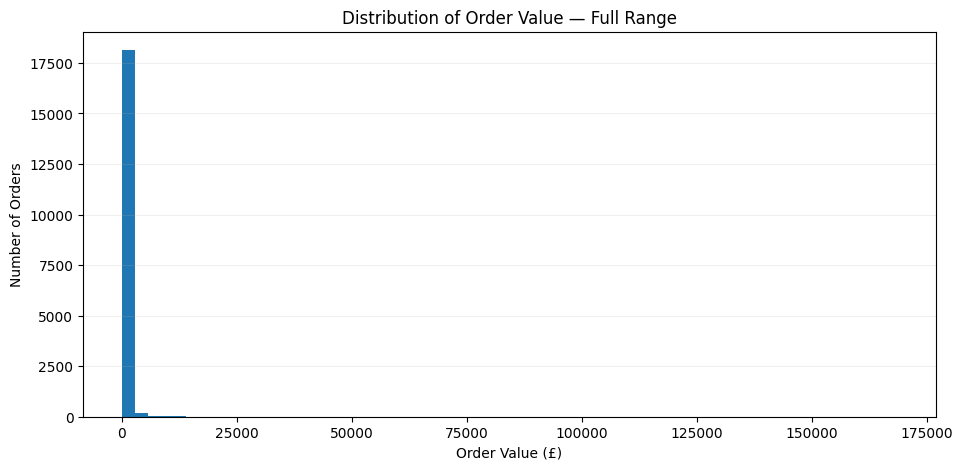

In [4]:
plt.figure(figsize=(11, 5))
plt.hist(order_value, bins=60)
plt.title("Distribution of Order Value — Full Range")
plt.xlabel("Order Value (£)")
plt.ylabel("Number of Orders")
plt.grid(axis="y", alpha=0.2)
plt.show()

### How to read this histogram

The full-range histogram is intentionally difficult to read in the main body because extreme high-value orders stretch the horizontal axis.

That is already an insight:

> A small number of very large orders can visually compress the majority of normal orders.

This is also one reason why the **mean** can be much larger than the **median**.

### A clearer view of the main body of the distribution

For visualization only, we can show orders up to the 99th percentile.

**Important:** we are not deleting the large orders from the dataset.  
We are only changing the viewing window so that the shape of the majority of orders becomes easier to see.

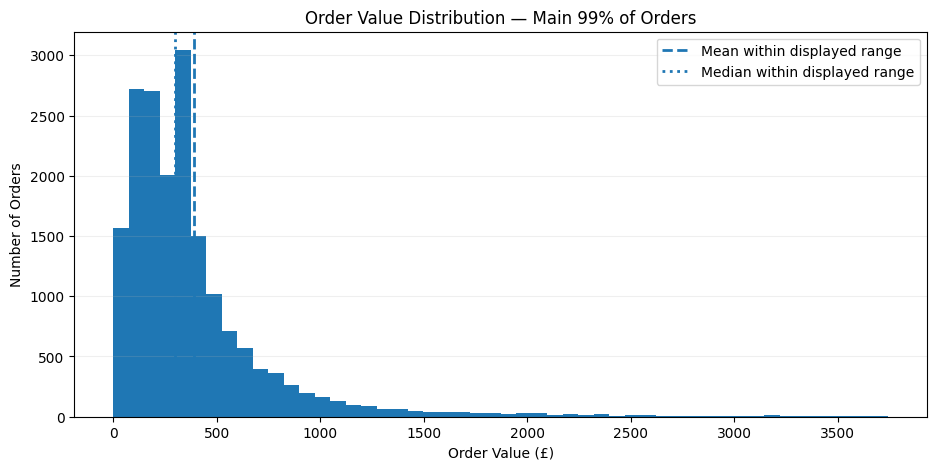

99th percentile: £3,762.47


In [5]:
p99 = np.percentile(order_value, 99)
main_body = order_value[order_value <= p99]

plt.figure(figsize=(11, 5))
plt.hist(main_body, bins=50)
plt.axvline(np.mean(main_body), linestyle="--", linewidth=2, label="Mean within displayed range")
plt.axvline(np.median(main_body), linestyle=":", linewidth=2, label="Median within displayed range")
plt.title("Order Value Distribution — Main 99% of Orders")
plt.xlabel("Order Value (£)")
plt.ylabel("Number of Orders")
plt.legend()
plt.grid(axis="y", alpha=0.2)
plt.show()

print(f"99th percentile: £{p99:,.2f}")

### Skewness — conceptual interpretation

The distribution has a **long tail toward larger order values**.

This is called **right skew** or **positive skew**.

Without using a skewness formula, we can describe the business meaning:

- most orders are relatively moderate,
- a smaller number of orders are very large,
- those large orders pull the mean upward,
- therefore the mean can be larger than the median.

This is a good example of why a data analyst should not report a single number without understanding the distribution behind it.

## 6. Quartiles and percentiles

Quartiles divide ordered data into four parts:

- `Q1` = 25th percentile
- `Q2` = 50th percentile = median
- `Q3` = 75th percentile

The interval from Q1 to Q3 contains the **middle 50% of orders**.

In [6]:
q1 = np.percentile(order_value, 25)
q2 = np.percentile(order_value, 50)
q3 = np.percentile(order_value, 75)

quartiles = pd.DataFrame({
    "Statistic": ["Q1 / 25th percentile", "Q2 / Median", "Q3 / 75th percentile"],
    "Order Value (£)": [q1, q2, q3]
})

quartiles

,Statistic,Order Value (£)
0,Q1 / 25th percentile,157.78
1,Q2 / Median,302.22
2,Q3 / 75th percentile,465.28


### Business interpretation of quartiles

- About 25% of orders are at or below Q1.
- About 50% of orders are at or below the median.
- About 75% of orders are at or below Q3.
- The range from Q1 to Q3 describes the middle half of customer order values.

Quartiles are especially useful because they are less sensitive to extreme values than the mean.

## 7. IQR and outlier bounds

The **Interquartile Range (IQR)** measures the width of the middle 50% of the data.

We then use the standard 1.5 × IQR rule to create lower and upper outlier bounds.

In [7]:
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

print(f"Q1: £{q1:,.2f}")
print(f"Q3: £{q3:,.2f}")
print(f"IQR: £{iqr:,.2f}")
print(f"Lower Bound: £{lower_bound:,.2f}")
print(f"Upper Bound: £{upper_bound:,.2f}")

Q1: £157.78
Q3: £465.28
IQR: £307.50
Lower Bound: £-303.47
Upper Bound: £926.53


### Important interpretation

An order outside the IQR bounds is **statistically unusual**.

It does **not** automatically mean:

- the order is wrong,
- the order is fraud,
- the order must be deleted.

It means:

> “This order is far from the middle of the distribution and deserves attention or separate analysis.”

In [8]:
outlier_mask = (order_value < lower_bound) | (order_value > upper_bound)
outlier_orders = order_value[outlier_mask]

high_outlier_mask = order_value > upper_bound
high_outliers = order_value[high_outlier_mask]

print("Total statistical outliers:", np.sum(outlier_mask))
print("High-value outliers:", np.sum(high_outlier_mask))
print(f"Share of all orders: {100*np.sum(outlier_mask)/len(order_value):.2f}%")

Total statistical outliers: 1460
High-value outliers: 1460
Share of all orders: 7.93%


## 8. Box plot — a compact summary of the distribution

A box plot helps us see:

- the median,
- Q1 and Q3,
- the IQR,
- whiskers,
- statistical outliers.

It is one of the best visual tools for comparing **typical values, spread, and unusual observations**.

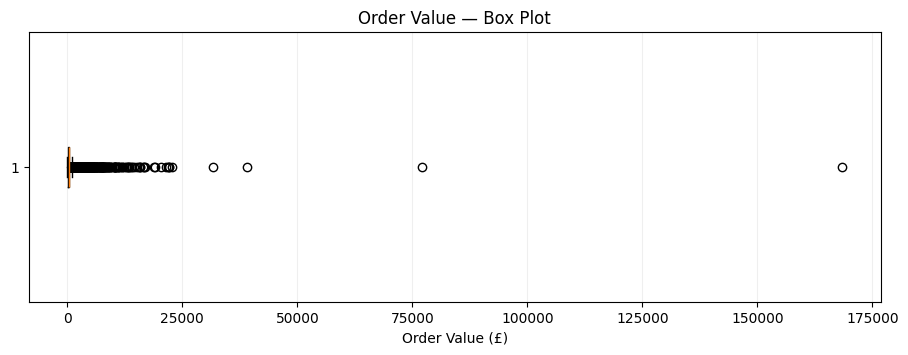

In [9]:
plt.figure(figsize=(11, 3.5))
plt.boxplot(order_value, vert=False)
plt.title("Order Value — Box Plot")
plt.xlabel("Order Value (£)")
plt.grid(axis="x", alpha=0.2)
plt.show()

### How to read this box plot

Because some orders are extremely large, the box may appear compressed near the left side.

This is not a problem with the chart. It is telling us something real:

> The order-value distribution has extreme high values relative to the middle 50% of the data.

For a manager, this suggests that “normal customer orders” and “very large orders” may deserve separate attention.

### Zoomed box plot for the main body

Again, this is only a visualization choice.  
The complete dataset remains unchanged.

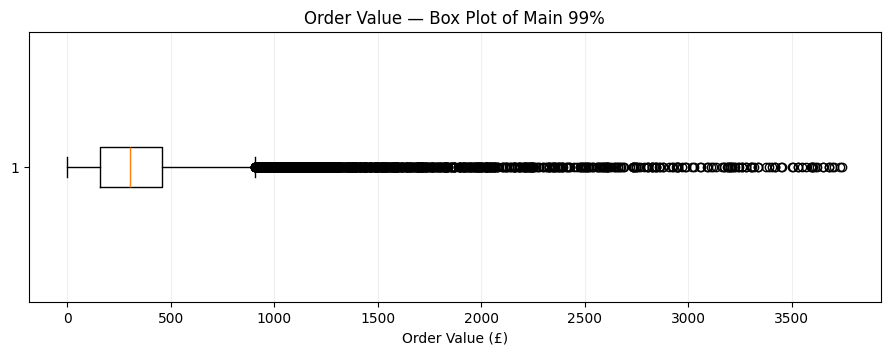

In [10]:
plt.figure(figsize=(11, 3.5))
plt.boxplot(main_body, vert=False)
plt.title("Order Value — Box Plot of Main 99%")
plt.xlabel("Order Value (£)")
plt.grid(axis="x", alpha=0.2)
plt.show()

## 9. Boolean masking — creating a business segment

Masking lets us turn a statistical rule into a group of orders.

Example business question:

> “Which orders are above the statistical upper outlier bound?”

In [11]:
high_value_orders = order_value[order_value > upper_bound]

print("Number of orders above the IQR upper bound:", len(high_value_orders))
print(f"Mean value of those orders: £{np.mean(high_value_orders):,.2f}")
print(f"Median value of those orders: £{np.median(high_value_orders):,.2f}")

Number of orders above the IQR upper bound: 1460
Mean value of those orders: £2,485.86
Median value of those orders: £1,415.45


### Another useful segment: top 10% of orders

A percentile can also define a business segment.

This is different from the IQR outlier rule:

- **IQR outlier:** statistically unusual relative to the distribution
- **Top 10%:** business ranking based on order value

In [12]:
p90 = np.percentile(order_value, 90)
top10_mask = order_value >= p90
top10_orders = order_value[top10_mask]

print(f"90th percentile: £{p90:,.2f}")
print("Orders in top 10% segment:", np.sum(top10_mask))
print(f"Median order value in top 10%: £{np.median(top10_orders):,.2f}")

90th percentile: £812.02
Orders in top 10% segment: 1841
Median order value in top 10%: £1,212.67


## 10. Covariance — do larger baskets tend to create larger orders?

Now we compare two numeric variables:

- `TotalQuantity`
- `OrderValueGBP`

Business question:

> “Do orders containing more units tend to generate more revenue?”

Before calculating anything, make a prediction about the **sign** of covariance.

In [13]:
covariance_matrix = np.cov(quantity, order_value)
cov_quantity_value = covariance_matrix[0, 1]

print("Covariance matrix:")
print(covariance_matrix)

print(f"\nCovariance between TotalQuantity and OrderValueGBP: {cov_quantity_value:,.2f}")

Covariance matrix:
[[ 951604.53155211 1488804.23010422]
 [1488804.23010422 2818697.05670438]]

Covariance between TotalQuantity and OrderValueGBP: 1,488,804.23


### How to interpret the sign

- Positive covariance: higher quantity tends to appear with higher order value.
- Negative covariance: higher quantity tends to appear with lower order value.
- Near-zero covariance: no clear shared direction.

### Important warning

Covariance does **not** prove causation.

Even if quantity and order value move together, covariance alone does not prove that one variable “causes” the other.

## 11. Scatter plot — visualize the relationship

A scatter plot makes the covariance idea visible.

Each point represents one order:

- horizontal position = total quantity,
- vertical position = order value.

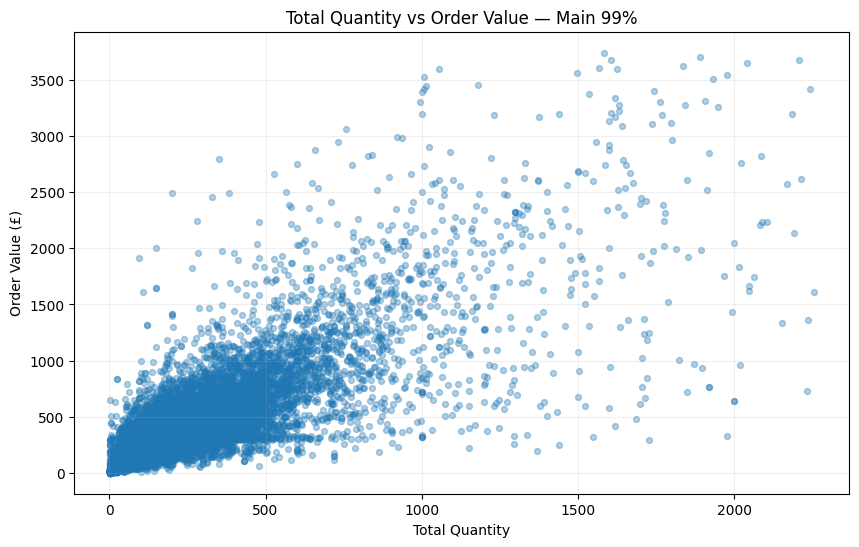

In [14]:
# Use the 99th percentile on both axes only to make the main relationship readable.
q99 = np.percentile(quantity, 99)
v99 = np.percentile(order_value, 99)
scatter_mask = (quantity <= q99) & (order_value <= v99)

plt.figure(figsize=(10, 6))
plt.scatter(quantity[scatter_mask], order_value[scatter_mask], alpha=0.35, s=18)
plt.title("Total Quantity vs Order Value — Main 99%")
plt.xlabel("Total Quantity")
plt.ylabel("Order Value (£)")
plt.grid(alpha=0.2)
plt.show()

### How to read the scatter plot

Look for the **overall direction**, not a perfect line.

If the cloud of points generally moves upward as quantity increases, the relationship is broadly positive.

But the spread of points also reminds us that:

> Order value depends on more than quantity alone — unit price and product mix also matter.

## 12. Monthly revenue — a management trend chart

The previous sections focused on statistics at the **order level**.

For a dashboard, managers also need a time-based view:

> “How does total revenue change over time?”

This section uses a small amount of Pandas only to prepare a monthly summary for visualization.

In [15]:
monthly_revenue = (
    df.groupby("OrderMonth", as_index=False)["OrderValueGBP"]
      .sum()
      .sort_values("OrderMonth")
)

monthly_revenue

,OrderMonth,OrderValueGBP
0,2010-12,"567,490.72"
1,2011-01,"564,026.64"
2,2011-02,"443,346.02"
3,2011-03,"584,562.85"
4,2011-04,"455,266.91"
5,2011-05,"660,481.90"
6,2011-06,"654,432.56"
7,2011-07,"592,731.90"
8,2011-08,"636,807.24"
9,2011-09,"940,900.81"


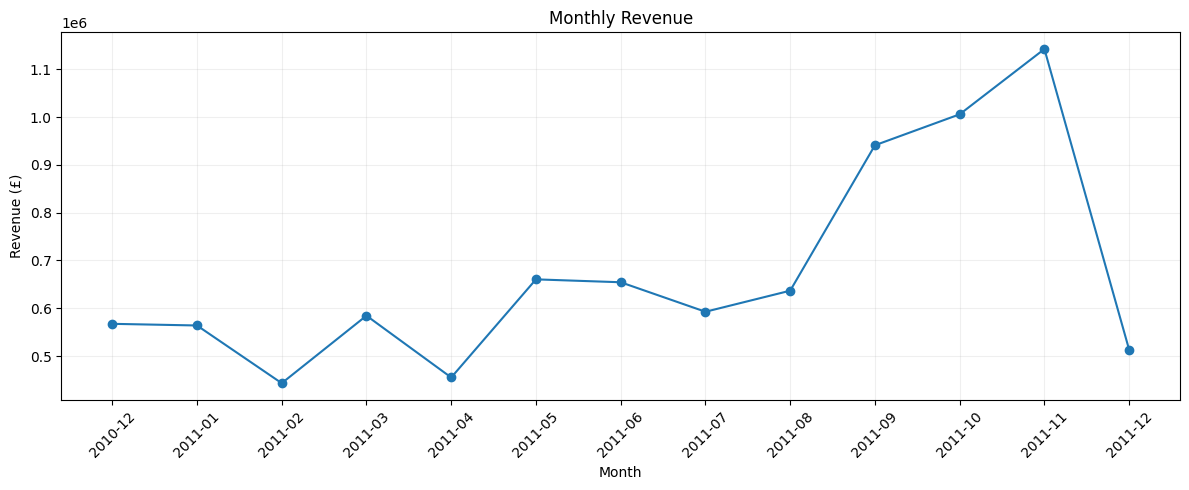

In [16]:
plt.figure(figsize=(12, 5))
plt.plot(monthly_revenue["OrderMonth"], monthly_revenue["OrderValueGBP"], marker="o")
plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

### How to read this chart

A line chart is appropriate because **time order matters**.

When presenting this chart to management, ask:

- Which months are strongest?
- Are there visible increases or decreases?
- Is the latest period comparable to the others?
- Does one unusual month deserve further investigation?

The goal is not just to say “revenue changed.”  
The goal is to identify where management attention should go.

## 13. Top countries by revenue

Another management question is:

> “Which markets generate the most revenue?”

A horizontal bar chart is useful because country names are categorical and ranking matters.

In [17]:
country_revenue = (
    df.groupby("Country", as_index=False)["OrderValueGBP"]
      .sum()
      .sort_values("OrderValueGBP", ascending=False)
      .head(10)
)

country_revenue

,Country,OrderValueGBP
35,United Kingdom,"7,265,862.23"
23,Netherlands,"283,889.34"
10,EIRE,"257,296.56"
14,Germany,"205,569.89"
13,France,"183,891.68"
0,Australia,"138,171.31"
30,Spain,"55,725.11"
32,Switzerland,"52,441.95"
19,Japan,"37,416.37"
3,Belgium,"36,927.34"


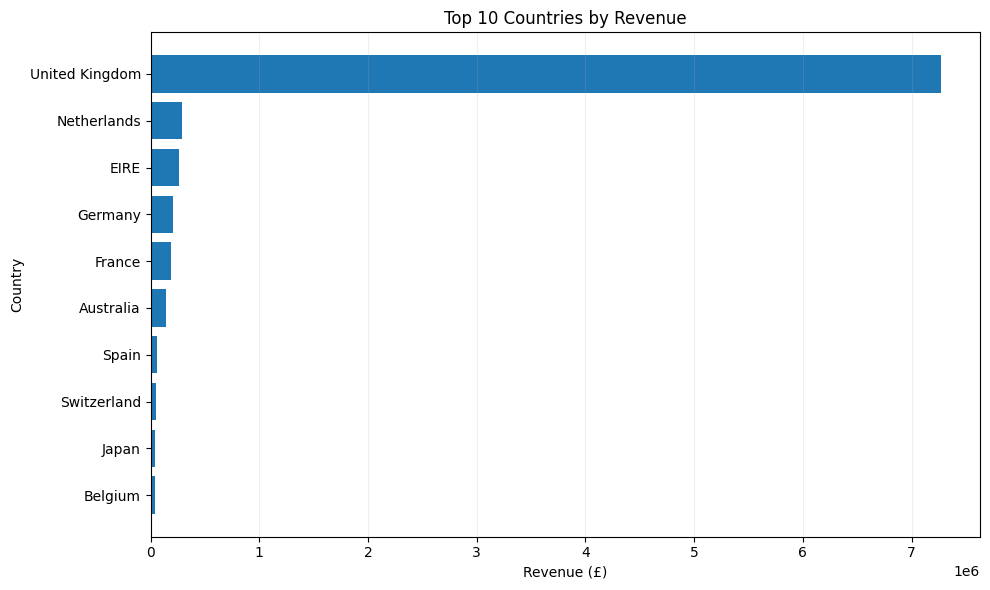

In [18]:
plot_country = country_revenue.sort_values("OrderValueGBP")

plt.figure(figsize=(10, 6))
plt.barh(plot_country["Country"], plot_country["OrderValueGBP"])
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Country")
plt.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()

### How to read this chart

This chart answers a ranking question.

A manager should be able to see immediately:

- which country contributes the most revenue,
- whether revenue is concentrated in one market,
- how large the gap is between top markets.

This is different from a histogram:

- histogram = shape of a numeric distribution,
- bar chart = comparison across categories.

## 14. Dashboard KPI design

A dashboard should not show every number we can calculate.

It should show the smallest set of metrics that helps a manager understand the business quickly.

Recommended KPI cards:

1. **Total Revenue**
2. **Number of Orders**
3. **Mean Order Value**
4. **Median Order Value**
5. **Maximum Order Value**

Why show both mean and median?

Because their difference helps reveal the effect of a right-skewed order-value distribution.

In [19]:
dashboard_kpis = {
    "Total Revenue": np.sum(order_value),
    "Number of Orders": len(order_value),
    "Mean Order Value": np.mean(order_value),
    "Median Order Value": np.median(order_value),
    "Maximum Order Value": np.max(order_value),
    "IQR Upper Bound": upper_bound,
    "Orders Above IQR Upper Bound": np.sum(order_value > upper_bound)
}

pd.DataFrame(
    [{"KPI": k, "Value": v} for k, v in dashboard_kpis.items()]
)

,KPI,Value
0,Total Revenue,"8,761,066.65"
1,Number of Orders,"18,402.00"
2,Mean Order Value,476.09
3,Median Order Value,302.22
4,Maximum Order Value,"168,469.60"
5,IQR Upper Bound,926.53
6,Orders Above IQR Upper Bound,"1,460.00"


## 15. Dashboard chart set

A strong dashboard for this class should include the same analytical ideas we used in the notebook.

### Chart 1 — Monthly Revenue
**Question:** How is the business changing over time?  
**Chart type:** Line chart  
**Interpretation:** Look for trend, peaks, dips, and unusual periods.

### Chart 2 — Top Countries by Revenue
**Question:** Which markets matter most?  
**Chart type:** Horizontal bar chart  
**Interpretation:** Compare ranking and concentration.

### Chart 3 — Order Value Histogram
**Question:** What does the distribution of customer orders look like?  
**Chart type:** Histogram  
**Interpretation:** Explain concentration, right skew, and why mean may exceed median.

### Chart 4 — Order Value Box Plot
**Question:** How spread out are order values, and where are the unusual orders?  
**Chart type:** Box plot  
**Interpretation:** Explain median, Q1, Q3, IQR, whiskers, and outliers.

### Chart 5 — Quantity vs Order Value
**Question:** Do larger baskets tend to generate higher-value orders?  
**Chart type:** Scatter plot  
**Interpretation:** Connect the visible direction to covariance.

### Required analytical callout
The dashboard should explicitly calculate and explain:

- Mean Order Value
- Median Order Value
- Q1 / Q3 / IQR
- IQR Upper Bound
- Number of orders above the upper bound
- Conceptual skewness interpretation

## 16. Executive summary — turning analysis into a story

A good analyst should be able to summarize the dashboard without talking about code.

A useful structure is:

1. **Typical behavior**  
   “The median order value is …”

2. **Distribution shape**  
   “The mean is higher than the median because the distribution has a right tail…”

3. **Unusual orders**  
   “Using the IQR rule, … orders are above the statistical upper bound…”

4. **Business trend**  
   “Monthly revenue shows …”

5. **Market concentration**  
   “The largest revenue contribution comes from …”

6. **Relationship between variables**  
   “Quantity and order value have a positive/negative covariance, suggesting …”

The goal of a dashboard is not to display charts.  
The goal is to make the business story **visible and understandable**.

## 17. Final classroom challenge

Imagine the CEO gives you only **60 seconds**.

Answer these questions without mentioning Python:

1. What is a typical order worth?
2. Why are the mean and median different?
3. What does the histogram tell you?
4. What does the box plot tell you?
5. Are high-value orders necessarily “bad data”?
6. Which chart would you show first to management, and why?
7. What is the single most important business insight from this dataset?

---

## Key idea of the lab

**Data → Statistic → Visualization → Interpretation → Business Decision → Dashboard**